# Numpy

## 0. Numpy 기능

넘파이에서 제공하는 기능
1. 빠른 배열 계산, 다차원 배열
2. 수학 함수
3. 배열 데이터 디스크에 작성 및 접근, 메모리 적재 파일 접근
4. 선형대수, 난수 생성, 푸리에 변환
5. C API

넘파이의 미쵸버린 성능 확인하기 ㄷㄷ

In [2]:
import numpy as np

# 길이 100만짜리 배열 투척 ㅋㅋ
numpy_arr = np.arange(1_000_000)
python_list = list(range(1_000_000))

In [3]:
%timeit numpy_arr * 2

2.34 ms ± 89.1 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [4]:
%timeit [x*2 for x in python_list]

43.2 ms ± 597 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


거이 머 최소 10배 이상 빠름

## 1. 다차원 배열

### 1.1 ndarray 선언과 특징

In [5]:
data = np.array([[1.5, -0.1, 3], [0, -3, 6.5]]) # array 함수 안에 리스트
data

array([[ 1.5, -0.1,  3. ],
       [ 0. , -3. ,  6.5]])

In [6]:
print("========스칼라 연산========")
print(10*data)
print("========행렬 연산========")
print(data+data)
print("========모양========")
print(data.shape)
print("========배열 인스턴스의 자료형========")
print(data.dtype)
print("========차원========")
print(data.ndim)

========스칼라 연산========
[[ 15.  -1.  30.]
 [  0. -30.  65.]]
========행렬 연산========
[[ 3.  -0.2  6. ]
 [ 0.  -6.  13. ]]
========모양========
(2, 3)
========배열 인스턴스의 자료형========
float64
========차원========
2


### 1.2 여러가지 배열을 생성하는 함수

In [7]:
np.zeros((1,3,4)) # (1,3,4) 모양의 0으로 초기화된 배열

array([[[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]]])

In [8]:
np.ones((3)) # 0 말고 1

array([1., 1., 1.])

In [9]:
np.empty((2,3)) # 초기화 되지 않은 배열을 작성. 그래서 아무 값이나 막 들어있음

array([[ 3. , -0.2,  6. ],
       [ 0. , -6. , 13. ]])

In [10]:
np.full((2,3), 7) # 7로 초기화된 (2,3)배열 생성

array([[7, 7, 7],
       [7, 7, 7]])

In [11]:
temp = np.array([1.0, 2.0, 3.0])
np.zeros_like(temp) # ones_like, empty_like, full_like
# 주어진 배열의 모양과 똑같은 0, 1, empty, full 배열 생성

array([0., 0., 0.])

In [12]:
np.arange(10) # 파이썬 range 함수의 array 버전임

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [13]:
my_list = [1,2,3]
my_arr = np.asarray(my_list)
my_arr is my_list # False 입력 데이터가 ndarray가 아니면 ndarray이면 복사 X, ndarray 새로 만듬

my_arr2 = np.asarray(my_arr) # ndarray이므로 기본 배열을 그대로 참조
my_arr is my_arr2 # True 같은 메모리를 가르킴

True

In [14]:
np.identity(4) # (4,4) 단위 행렬 생성

array([[1., 0., 0., 0.],
       [0., 1., 0., 0.],
       [0., 0., 1., 0.],
       [0., 0., 0., 1.]])

In [15]:
np.eye(5,6, k=2) # (5,6) 행렬에서 주대각선보다 2칸 위를 1로 채움

array([[0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0.]])

### 1.3 ndarray의 자료형

넘파이는 다양한 자료형을 지원한다
int, uint8, 16, 32, 64
float16, 32, 64, 128
object 파이썬 객체형. 보통 태뷸러 데이터 분석을 할때 문자열 자료형이 object로 나옴

In [16]:
arr_float64 = np.array([1,2,3], dtype=np.float64) # 배정밀도(64비트) 지정. 딥러닝 시에는 반정밀도(16비트) 실수만 사용해도 성능에 문제없음
arr_float64.dtype

dtype('float64')

명시적으로 형 변환하기

In [17]:
arr = np.array([1,2,3,4,5])
print(arr.dtype)
float_arr = arr.astype(np.float64)
print(float_arr.dtype)

int64
float64


### 1.4 배열의 산술연산

In [18]:
arr = np.array([[1., 2., 3.], [4., 5., 6.,]])

arr*arr # 각 배열의 원소단위로 계산한다

array([[ 1.,  4.,  9.],
       [16., 25., 36.]])

In [19]:
1/arr # 스칼라와의 연산은 기본 행렬 연산과 똑같다

array([[1.        , 0.5       , 0.33333333],
       [0.25      , 0.2       , 0.16666667]])

In [20]:
# 동일 크기의 배열간 비교연산은 불리언 값을 반환한다
arr2 = np.array([[1,2,10], [4,5,8]], dtype=np.float64)
arr2>arr

array([[False, False,  True],
       [False, False,  True]])

### 1.5 인덱싱과 슬라이싱

1차원 배열

In [21]:
arr = np.arange(10)

# 1차원 배열은 파이썬 리스트와 유사
print(arr[3:5])
arr[3:5] = 10
print(arr)

[3 4]
[ 0  1  2 10 10  5  6  7  8  9]


In [22]:
arr_slice = arr[3:5]
print(arr_slice)
arr_slice[0] = 3
print(arr)

[10 10]
[ 0  1  2  3 10  5  6  7  8  9]


다차원 배열

In [23]:
arr2d = np.array([[1,2,3], 
                  [4,5,6]], dtype=np.float64)

print(arr2d[0])      # 0번째 행
print(arr2d[0][1])   # 0번째 행, 1번째 열
print(arr2d[0, 1])    # 이렇게도 접근 가능

[1. 2. 3.]
2.0
2.0


In [24]:
arr3d = np.array([[ [1,2,3],
                    [4,5,6] ],
                  
                  [ [7,8,9], 
                   [10,11,12] ]]) # (2,2,3)
print(arr3d.shape)
print(arr3d[0])
print(arr3d[0,1])
print(arr3d[0,1,2])

(2, 2, 3)
[[1 2 3]
 [4 5 6]]
[4 5 6]
6


다차원 배열 슬라이싱

In [25]:
arr2d = np.array([[1,2,3],
                  [4,5,6],
                  [7,8,9]])
print(arr2d[:2]) # 0번 축 2 전까지
print(arr2d[:2, 1:]) # 0번 축(행)은 2 전까지, 1번 축(열)은 1부터

[[1 2 3]
 [4 5 6]]
[[2 3]
 [5 6]]


### 1.6 불리언으로 값 선택

In [26]:
names = np.array(['A', 'B', 'C', 'A', 'C', 'B', 'B'])
data = np.array([[4,7], [0,2], [-5,6], [0,0], [1,2], [-12,-4], [3,4]])

names == 'A' # 불리언 배열 반환

array([ True, False, False,  True, False, False, False])

In [27]:
data[names == 'A'] # 불리언 배열을 배열의 인덱스로 사용! 0, 3번째만 True

array([[4, 7],
       [0, 0]])

In [28]:
print(data[names == 'A', :1])
print(data[names == 'A', 1])

[[4]
 [0]]
[7 0]


In [29]:
data[data<0] = 0
data # data 0 미만은 0으로

array([[4, 7],
       [0, 2],
       [0, 6],
       [0, 0],
       [1, 2],
       [0, 0],
       [3, 4]])

### 1.7 팬시 색인 fancy indexing

In [30]:
arr = np.zeros((8,4))

for i in range(8):
    arr[i] = i
    
arr

array([[0., 0., 0., 0.],
       [1., 1., 1., 1.],
       [2., 2., 2., 2.],
       [3., 3., 3., 3.],
       [4., 4., 4., 4.],
       [5., 5., 5., 5.],
       [6., 6., 6., 6.],
       [7., 7., 7., 7.]])

In [31]:
# 특정한 순서로 행의 하위집합 선택
arr[ [4,3,2,1] ]

array([[4., 4., 4., 4.],
       [3., 3., 3., 3.],
       [2., 2., 2., 2.],
       [1., 1., 1., 1.]])

In [32]:
arr = np.arange(32).reshape((8, 4))
arr

array([[ 0,  1,  2,  3],
       [ 4,  5,  6,  7],
       [ 8,  9, 10, 11],
       [12, 13, 14, 15],
       [16, 17, 18, 19],
       [20, 21, 22, 23],
       [24, 25, 26, 27],
       [28, 29, 30, 31]])

In [33]:
arr[[1,5,7,2],
    [0,3,1,2]] # (1,0) (5,3) (7,1) (2,2)

array([ 4, 23, 29, 10])

In [34]:
arr[[1,5,7,2]][:,[0,3,1,2]]

array([[ 4,  7,  5,  6],
       [20, 23, 21, 22],
       [28, 31, 29, 30],
       [ 8, 11,  9, 10]])

### 1.8 축 바꾸기

In [35]:
arr = np.arange(15).reshape((3,5))
arr.T

array([[ 0,  5, 10],
       [ 1,  6, 11],
       [ 2,  7, 12],
       [ 3,  8, 13],
       [ 4,  9, 14]])

In [36]:
# 내적
print(np.dot(arr, arr.T))
print(arr@arr.T)

[[ 30  80 130]
 [ 80 255 430]
 [130 430 730]]
[[ 30  80 130]
 [ 80 255 430]
 [130 430 730]]


## 2. 난수 생성

In [37]:
samples = np.random.standard_normal(size=(4,4)) # 표준정규분포

생성기를 명시적으로 설정해서 사용

In [38]:
rng = np.random.default_rng(seed=12345)
data = rng.standard_normal((2,3))
data

array([[-1.42382504,  1.26372846, -0.87066174],
       [-0.25917323, -0.07534331, -0.74088465]])

In [39]:
np.random.permutation([4,2,1,3,2,3]) # 섞기
np.random.permutation(3) # 순열


array([0, 2, 1], dtype=int32)

여러 분포 지원
standard_normal, binomial, normal, beta, chisquare, gamma, uniform

## 3. ufunc 유니버셜 함수

In [40]:
arr = np.arange(3)
np.sqrt(arr)
np.exp(arr)

array([1.        , 2.71828183, 7.3890561 ])

In [41]:
x = rng.standard_normal(8)
y = rng.standard_normal(8)

np.maximum(x,y)

array([-0.46695317,  0.6488928 ,  0.78884434, -1.25666813,  2.34740965,
        1.39897899,  1.32229806,  0.90219827])

In [42]:
x = rng.standard_normal(5) * 10

remainder, whole_part = np.modf(x)
print(remainder)
print(whole_part)

[ 0.02919341 -0.21582734 -0.58189261  0.49483932 -0.43601072]
[  9. -16.  -1.   4. -13.]


ufunc는 out 인수를 사용해 바로 할당할 수 있다

In [43]:
x2 = np.zeros_like(x)

np.add(x, 1, out=x2)
x2

array([ 10.02919341, -15.21582734,  -0.58189261,   5.49483932,
       -12.43601072])

다양한 연산을 지원한다

## 4. 배열 기반 프로그래밍

In [44]:
points = np.arange(-5,5,0.01)
xs, ys = np.meshgrid(points, points) # 가능한 (x,y) 짝을 만들 수 있는 2차원 배열 2개 반환
z = np.sqrt(xs**2 + ys**2)

Text(0.5, 1.0, 'Image plot of $\\sqrt{x^2 + y^2}$ for a grid of values')

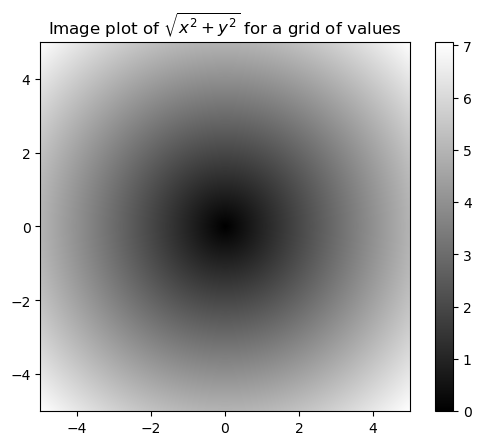

In [45]:
import matplotlib.pyplot as plt
plt.imshow(z, cmap=plt.cm.gray, extent=[-5,5,-5,5])
plt.colorbar()
plt.title("Image plot of $\sqrt{x^2 + y^2}$ for a grid of values")

### 4.1. 배열 연산으로 조건부 표현

In [46]:
xarr = np.array([1.1, 1.2, 1.3, 1.4, 1.5])
yarr = np.array([2.1, 2.2, 2.3, 2.4, 2.5])
cond = np.array([True, False, True, True, False])

In [47]:
# where을 알기 전의 나
# 파이써닉함
# 기분 좋음
# 모두에게 친절함
# 느림
result = [(x if c else y)
            for x,y,c in zip(xarr,yarr,cond)]
result

[np.float64(1.1),
 np.float64(2.2),
 np.float64(1.3),
 np.float64(1.4),
 np.float64(2.5)]

In [48]:
# where을 알고 난 후
# 내장함수를 업신여김
# 까칠함
# 기분나쁨
# 빠름
result = np.where(cond, xarr, yarr) # 불리안배열, True일때, False일때
result

array([1.1, 2.2, 1.3, 1.4, 2.5])

### 4.2. 수학, 통계 메서드

In [49]:
arr = rng.standard_normal((5,4))
arr

array([[-0.08168759,  1.72473993,  2.61815943,  0.77736134],
       [ 0.8286332 , -0.95898831, -1.20938829, -1.41229201],
       [ 0.54154683,  0.7519394 , -0.65876032, -1.22867499],
       [ 0.25755777,  0.31290292, -0.13081169,  1.26998312],
       [-0.09296246, -0.06615089, -1.10821447,  0.13595685]])

In [54]:
print(arr.mean())
print(arr.sum())
print(arr.sum(axis=1)) # 모든 열의 합 - 가로
print(arr.sum(axis=0)) # 모든 행의 합 - 세로
print(arr.cumsum()) # 중간 계산값을 담고 있는 배열

# sum, mean, std, var, min, max, argmin(최솟값 인덱스), argmax, cumsum, cumprod(누적곱)

0.11354248839817911
2.270849767963582
[ 5.03857311 -2.75203542 -0.59394908  1.70963212 -1.13137096]
[ 1.45308775  1.76444304 -0.48901534 -0.45766568]
[-0.08168759  1.64305234  4.26121177  5.03857311  5.86720631  4.90821799
  3.69882971  2.28653769  2.82808452  3.58002392  2.9212636   1.69258861
  1.95014638  2.2630493   2.13223761  3.40222073  3.30925827  3.24310738
  2.13489292  2.27084977]


### 4.3. 불리언 배열 메서드

In [64]:
arr = rng.standard_normal(100)
(arr>0).sum() # 양수인 값의 개수

np.int64(51)

In [67]:
bool_arr = np.array([True, False, True, True])
bool_arr.any() # 하나 이상의 True 있나?
bool_arr.all() # 모두 True인가?

np.False_

### 4.4. 정렬

In [69]:
arr = rng.standard_normal(6)
arr.sort()
arr

array([-1.61927444, -1.30547512,  0.06880822,  0.61210855,  1.39204144,
        1.96032218])

In [71]:
arr = np.array([[1,4,3],
                [135,213,3],
                [5,9,2]])
arr.sort(axis=0) # 각 열 값 정렬
arr

array([[  1,   4,   2],
       [  5,   9,   3],
       [135, 213,   3]])

### 4.5. 집합

In [73]:
names = np.array(["A", "B", "C", "A", "B", "C", "C"])
np.unique(names) # 중복 원소 제거, 남은 원소 정렬 반환

array(['A', 'B', 'C'], dtype='<U1')

In [74]:
values = np.array([6,0,0,4,3,5,6])
np.in1d(values, [2,3,6])

C:\Users\devsa\AppData\Local\Temp\ipykernel_29760\513927943.py:2: DeprecationWarning: `in1d` is deprecated. Use `np.isin` instead.
  np.in1d(values, [2,3,6])


array([ True, False, False, False,  True, False,  True])

1. unique(x) 배열 x에서 중복 원소 제거, 정렬 해서 반환
2. intersect1d(x,y) 배열 x와 y에 공통으로 존재하는 원소 정렬해 반환
3. union1d(x,y) 두 배열의 합집합 반환
4. in1d(x,y) x의 원소가 y의 원포 에 포함되는지 불리언 배열 반환
5. setdiff1d(x,y) x와 y의 차집합
6. setxor1d(x,y) xor

### 4.6. 선형대수

In [81]:
x = np.array([[1.,2.,3.],[4.,5.,6.]])
y = np.array([[1.,2.,3.],[4.,5.,6.]])

In [82]:
# element-wise 곱
x*y

array([[ 1.,  4.,  9.],
       [16., 25., 36.]])

In [83]:
# 행렬곱
np.dot(x, y.T)

array([[14., 32.],
       [32., 77.]])

In [ ]:
from numpy.linalg import trace, det, eig, inv, pinv, qr, svd, solve, lstsq # 여러가지 선형대수학 공식